In [1]:
# Load libraries

import os
import pandas
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from scipy import stats
import sklearn.model_selection
import shutil

# import my extended pySuStaIn model
from apoe4_sustain import ZscoreSustain_APOE4
# import simulation function
from genetics_simulation_utils import genetics_simulation


/Users/mihaelacroitor/anaconda3/envs/apoe4_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


1. Simulate biomarkers using zscore SuStaIn model and a categorical variable: APOE carrier status based on fixed genetic probabilities

In [2]:
# define hyper-parameters of simulation
# Configure dataset dimensions
M_patients = 1000
N_biomarkers = 5
N_subtypes = 2
gt_fractions = np.array([0.45, 0.55])


#Define the explicit ground-truth genetic profiles for this sandbox run
W_true_target = np.array([
    [0.80, 0.15, 0.05],  # Subtype 0: High Category 0 anchor
    [0.10, 0.30, 0.60]   # Subtype 1: High Category 2 anchor
])

# #Uniform case
# W_true_target = np.array([
#     [1/3, 1/3, 1/3],  # Subtype 0: High Category 0 anchor
#     [1/3, 1/3, 1/3]   # Subtype 1: High Category 2 anchor
# ])


In [3]:
# N_subtypes = 1
# gt_fractions = np.array([1.0])
# W_true_target = np.array([
#     [1/3, 1/3, 1/3],  # Subtype 0: High Category 0 anchor[1/3, 1/3, 1/3]   # Subtype 1: High Category 2 anchor
# ])


In [4]:
# Generate the dataset in-memory
df, Z_vals, Z_max, gt_ordering, W_true = genetics_simulation(
    N=N_biomarkers, 
    M=M_patients, 
    N_S_gt=N_subtypes, 
    gt_fractions=gt_fractions, 
    W_true=W_true_target, 
    use_midpoints=False, # Set to True if you want to test your supervisor's midpoint variant
    save=False
)

df

Generator(PCG64)
Rng from before


,Biomarker 0,Biomarker 1,Biomarker 2,Biomarker 3,Biomarker 4,ground_truth_subtypes,ground_truth_stages,apoe_status
0,-1.522652,0.423807,-0.886022,1.384926,2.839217,0,0,0
1,-0.533610,-0.437999,0.032039,0.133664,0.214144,0,0,0
2,-0.538003,1.157656,-1.271270,-0.431400,0.388625,0,0,1
3,0.175785,0.931265,0.297317,-1.859538,0.050729,0,0,0
4,0.211271,-0.128404,1.048960,1.194235,0.292587,0,0,1
...,...,...,...,...,...,...,...,...
995,1.327214,3.199153,0.984704,2.703223,1.160783,2,8,2
996,-0.224812,2.132583,0.933958,0.827619,3.337075,2,5,0
997,1.870568,4.781255,5.531260,5.008234,5.302229,1,15,0
998,1.256619,-0.370665,-0.163473,0.700177,2.547363,2,1,2


In [5]:
# Extract raw arrays for the model execution
BiomarkerNames = [f'Biomarker {i}' for i in range(N_biomarkers)]
X_data = df[BiomarkerNames].values
y_genetics = df['apoe_status'].values

print(f"Generated data matrix shape: {X_data.shape}")
print(f"Generated genetic vector shape: {y_genetics.shape}")

Generated data matrix shape: (1000, 5)
Generated genetic vector shape: (1000,)


In [6]:
N_startpoints = 15
N_S_max = N_subtypes
N_iterations_MCMC = int(1e4)
#output_folder = os.path.join(os.getcwd(), 'MRI_Sustain_5features_all')



In [7]:
dataset_name = 'simulated_data_genetics_model'
output_folder = os.path.join(os.getcwd(), dataset_name)
sustain_input = ZscoreSustain_APOE4(X_data,
                                Z_vals,
                                Z_max,
                                BiomarkerNames,
                                N_startpoints,
                                N_S_max, 
                                N_iterations_MCMC, 
                                output_folder, 
                                dataset_name, 
                                False,
                                apoe4_status = y_genetics,
                                #apoe4_status = gender_status_array,
                                apoe_flag = True)

1000 patients initially
 -> Detected 3 unique genetic categories: [0 1 2]
1000 patients with non null apoe4 carrier status
 -> [Genetics Setup] Global cohort background frequencies calculated: [0.439 0.23  0.331]
Running genetic weighted SuStaIn 


Run SuStaIn 

In [8]:
# delete previous pickle files
if os.path.exists(output_folder):
    shutil.rmtree(output_folder)

In [9]:
# make the output directory if it's not already created
if not os.path.isdir(output_folder):
    os.mkdir(output_folder)

In [10]:

samples_sequence,     \
ml_f_EM,            \
ml_subtype,         \
prob_ml_subtype,    \
ml_stage,           \
prob_ml_stage,      \
prob_subtype_stage,         = sustain_input.run_sustain_algorithm()


Failed to find pickle file: /Users/mihaelacroitor/apoe4_informed/simulated_data_genetics_model/pickle_files/simulated_data_genetics_model_subtype0.pickle. Running SuStaIn model for 0 subtype.
Finding ML solution to 1 cluster problem
Using alternating method
Genetic weight estimation converged at iteration 1
EM converged in 5 iterations
Using alternating method
Genetic weight estimation converged at iteration 1
EM converged in 3 iterations
Using alternating method
Genetic weight estimation converged at iteration 1
EM converged in 2 iterations
Using alternating method
Genetic weight estimation converged at iteration 1
EM converged in 4 iterations
Using alternating method
Genetic weight estimation converged at iteration 1
EM converged in 3 iterations
Using alternating method
Genetic weight estimation converged at iteration 1
EM converged in 4 iterations
Using alternating method
Genetic weight estimation converged at iteration 1
EM converged in 4 iterations
Using alternating method
Genetic

MCMC Iteration: 100%|██████████| 10000/10000 [00:05<00:00, 1914.30it/s]



   FINAL MODEL SUBTYPE COHORT FRACTIONS
 -> Subtype 1 Cohort Size: 100.00% of dataset

   SUSTAIN GENETIC PRIOR PROFILE (EM MAX LIKELIHOOD)
 -> COHORT BACKGROUND BASELINE : [Cat_0: 0.4390, Cat_1: 0.2300, Cat_2: 0.3310]
------------------------------------------------------------
 -> Subtype 1 Profile Prior : [Cat_0: 0.4390, Cat_1: 0.2300, Cat_2: 0.3310]

Failed to find pickle file: /Users/mihaelacroitor/apoe4_informed/simulated_data_genetics_model/pickle_files/simulated_data_genetics_model_subtype1.pickle. Running SuStaIn model for 1 subtype.
Splitting cluster 1 of 1
Reindexing
 + Resolving 2 cluster problem
Using alternating method
Genetic weight estimation converged at iteration 1
EM converged in 4 iterations
Using alternating method
Genetic weight estimation converged at iteration 1
EM converged in 4 iterations
Using alternating method
Genetic weight estimation converged at iteration 14
EM converged in 15 iterations
Using alternating method
Genetic weight estimation converged at it

MCMC Iteration: 100%|██████████| 10000/10000 [00:14<00:00, 676.02it/s]



   FINAL MODEL SUBTYPE COHORT FRACTIONS
 -> Subtype 1 Cohort Size: 52.82% of dataset
 -> Subtype 2 Cohort Size: 47.18% of dataset

   SUSTAIN GENETIC PRIOR PROFILE (EM MAX LIKELIHOOD)
 -> COHORT BACKGROUND BASELINE : [Cat_0: 0.4390, Cat_1: 0.2300, Cat_2: 0.3310]
------------------------------------------------------------
 -> Subtype 1 Profile Prior : [Cat_0: 0.0890, Cat_1: 0.3102, Cat_2: 0.6008]
 -> Subtype 2 Profile Prior : [Cat_0: 0.8269, Cat_1: 0.1411, Cat_2: 0.0320]



### Proof 1 Does the model recover correct params?

## Does the EM converge to max likelihood?

In [19]:
s = N_subtypes - 1
pickle_filename_s = output_folder + '/pickle_files/' + dataset_name + '_subtype' + str(s) + '.pickle'
pk = pandas.read_pickle(pickle_filename_s)
ml_likelihood_mat_EM = pk["ml_likelihood_mat_EM"]

ml_genetic_weights_EM = pk["ml_genetic_weights_EM"]
ml_sequence_EM = pk["ml_sequence_EM"]
em_likelihood_histories = pk["em_likelihood_histories"]

In [23]:
em_likelihood_histories[:,2]

array([-9569.44481836, -9541.95064463, -9530.20264061, -9524.84958351,
       -9522.28844794, -9521.01561976, -9520.3644328 , -9520.02387867,
       -9519.84278849, -9519.74526725, -9519.69223901, -9519.66318857,
       -9519.64718164, -9519.64718164,            nan,            nan,
                  nan,            nan,            nan,            nan,
                  nan,            nan,            nan,            nan,
                  nan,            nan,            nan,            nan,
                  nan,            nan,            nan,            nan,
                  nan,            nan,            nan,            nan,
                  nan,            nan,            nan,            nan,
                  nan,            nan,            nan,            nan,
                  nan,            nan,            nan,            nan,
                  nan,            nan,            nan,            nan,
                  nan,            nan,            nan,            nan,
      

In [13]:
print(f"Matrix Shape: {em_likelihood_histories.shape}") # Should be (100, 15)
print(f"Total Non-NaN points per startpoint column:")
print(np.sum(~np.isnan(em_likelihood_histories), axis=0))

Matrix Shape: (100, 15)
Total Non-NaN points per startpoint column:
[14 14 14 14 14 14 14 14 14 14 14 14 14 14 14]


In [14]:
import numpy as np
import pandas as pd

# 1. Load your saved model pickle
s = N_subtypes - 1 # Subtype loop index indicator
pickle_filename_s = f"{output_folder}/pickle_files/{dataset_name}_subtype{s}.pickle"
pk = pd.read_pickle(pickle_filename_s)

ml_likelihood_mat_EM = pk["ml_likelihood_mat_EM"]
em_likelihood_histories = pk["em_likelihood_histories"]
print('EM lik history',em_likelihood_histories.shape)

# 2. Identify the global maximum value found in this run
global_max_val = np.max(ml_likelihood_mat_EM)

# 3. Find which startpoint IDs reached this max (allowing a tiny floating-point tolerance)
epsilon = 1e-2
winning_startpoints_mask = np.abs(ml_likelihood_mat_EM - global_max_val) <= epsilon
winning_indices = np.where(winning_startpoints_mask)[0]
print(winning_indices)

# 4. Calculate convergence steps across all runs by counting non-NaN markers
all_convergence_steps = np.sum(~np.isnan(em_likelihood_histories), axis=0)

# 5. Filter to keep ONLY the winning startpoints
winning_speeds = all_convergence_steps[winning_indices]

# ---------------------------------------------------------------------
# PRESENTATION REPORT
# ---------------------------------------------------------------------
print("=" * 60)
print(f" WINNING STARTPOINTS CONVERGENCE SPEED REPORT (Max Lik: {global_max_val:.2f})")
print("=" * 60)
print(f" Total Startpoints: {len(ml_likelihood_mat_EM)}")
print(f" Global Winners:    {len(winning_indices)} / {len(ml_likelihood_mat_EM)}")
print("-" * 60)

for idx, steps in zip(winning_indices, winning_speeds):
    print(f" -> Startpoint {idx + 1:2d}: Hit True Global Max in {steps:2d} iterations")

print("-" * 60)
print(f" Avg speed of winning tracks: {np.mean(winning_speeds):.1f} iterations")
print("=" * 60)

EM lik history (100, 15)
[0]
 WINNING STARTPOINTS CONVERGENCE SPEED REPORT (Max Lik: -9519.65)
 Total Startpoints: 1
 Global Winners:    1 / 1
------------------------------------------------------------
 -> Startpoint  1: Hit True Global Max in 14 iterations
------------------------------------------------------------
 Avg speed of winning tracks: 14.0 iterations


In [15]:
# compare estimated vs true params
print("True seq", gt_ordering)
print("Estimated seq", ml_sequence_EM)
print("Estimated fractions",ml_f_EM)
print("True genetic weights",W_true_target)
print("Estimated genetics",ml_genetic_weights_EM)

True seq [[ 4.  1.  2.  3.  8.  6. 13.  9.  7. 11. 14. 12.  0.  5. 10.]
 [ 4.  1.  3.  9.  6. 11.  8.  0.  2.  5. 10.  7. 12. 13. 14.]]
Estimated seq [[ 4.  1.  3.  9.  6. 11.  8.  0.  5.  2. 10.  7. 12. 13. 14.]
 [ 4.  2.  1.  6.  3.  8. 13.  9.  7. 11. 14. 12.  0.  5. 10.]]
Estimated fractions [[0.52815558 0.52815558 0.52815558 ... 0.52509432 0.52485526 0.52485526]
 [0.47184442 0.47184442 0.47184442 ... 0.47490568 0.47514474 0.47514474]]
True genetic weights [[0.8  0.15 0.05]
 [0.1  0.3  0.6 ]]
Estimated genetics [[0.08898244 0.31024237 0.60077518]
 [0.82689934 0.14107314 0.03202753]]


In [16]:
# calculate actual max likelihood from simulated parameters
sustainData = sustain_input._AbstractSustain__sustainData
true_max_lik,_ ,_, _, _ = sustain_input._calculate_likelihood(sustainData, gt_ordering,gt_fractions, W_true)
print('True max',true_max_lik)

# did any starting points converge?
epsilon_tolerance = 0.1
converged_to_true_lik = (ml_likelihood_mat_EM >= true_max_lik) | \
                       (np.abs(ml_likelihood_mat_EM - true_max_lik) <= epsilon_tolerance)
gt_indices = np.where(converged_to_true_lik)[0]
converged = len(gt_indices)
print(f" {converged} starting points converged to true max lik {true_max_lik}")

# find max EM lik, and how many times it is reached;
max_val = np.max(ml_likelihood_mat_EM)
max_indices = np.where(np.isclose(ml_likelihood_mat_EM, max_val))[0]
occurrence_count = len(max_indices)
print(f"Maximum Likelihood Value: {max_val} reached by {occurrence_count} startingpoints")



True max -9526.239705734522
 1 starting points converged to true max lik -9526.239705734522
Maximum Likelihood Value: -9519.64718163649 reached by 1 startingpoints


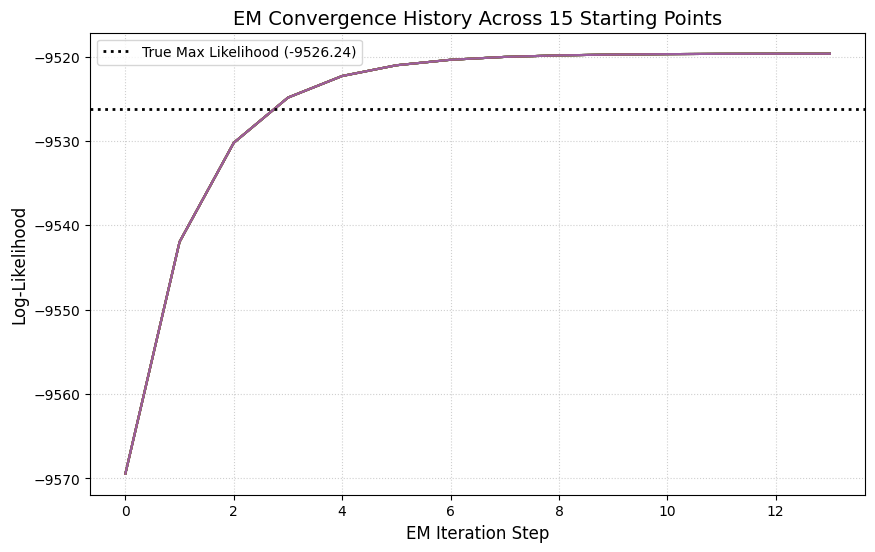

In [17]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Set up the figure size
plt.figure(figsize=(10, 6))

# 2. Plot the array directly
# Matplotlib plots each column (startpoint) as a separate colored line
plt.plot(em_likelihood_histories, linewidth=1.5, alpha=0.8)

# 3. Add your ground-truth maximum likelihood as a horizontal dotted line
# 'ls=":"' makes it dotted, 'color="black"' ensures high contrast, 'zorder=5' keeps it on top
plt.axhline(y=true_max_lik, color="black", linestyle=":", linewidth=2, label=f"True Max Likelihood ({true_max_lik:.2f})")


# 4. Add styling and descriptive labels
plt.xlabel("EM Iteration Step", fontsize=12)
plt.ylabel("Log-Likelihood", fontsize=12)
plt.title(f"EM Convergence History Across {em_likelihood_histories.shape[1]} Starting Points", fontsize=14)

plt.legend()
# 4. Clean up the grid presentation
plt.grid(True, linestyle=":", alpha=0.6)

# 5. Show the plot
plt.show()

IndexError: index 15 is out of bounds for axis 1 with size 15

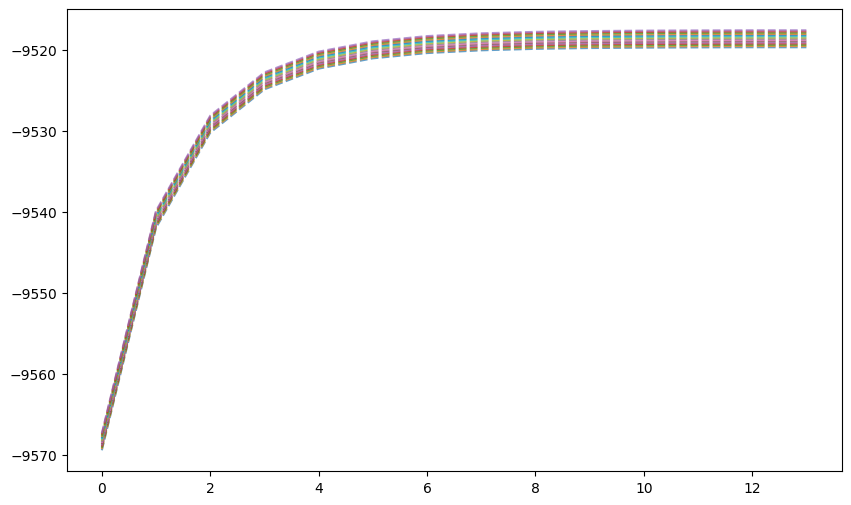

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# Create a clean plotting window
plt.figure(figsize=(10, 6))

# Loop through all 15 columns of your recovered history matrix
for worker_id in range(em_likelihood_histories.shape[0]):
    # Add a tiny, unique offset fraction to each line so they don't cover each other
    jitter_factor = worker_id * 0.15 
    
    plt.plot(
        em_likelihood_histories[:, worker_id] + jitter_factor, 
        linestyle='--', 
        alpha=0.7, 
        label=f"Seed {worker_id + 1}"
    )

plt.axhline(true_max_lik, color='black', linestyle=':', label='Ground Truth Ceiling')
plt.title("Separated EM Startpoint Trajectories (Jitter Applied)")
plt.xlabel("EM Iteration Step")
plt.ylabel("Log-Likelihood")
plt.show()

In [ ]:
# for each subtype model
for s in range(N_S_max):
    # load pickle file (SuStaIn output) and get the sample log likelihood values
    pickle_filename_s = output_folder + '/pickle_files/' + dataset_name + '_subtype' + str(s) + '.pickle'
    pk = pandas.read_pickle(pickle_filename_s)
    samples_likelihood = pk["samples_likelihood"]
    
    # plot the values as a line plot
    fig0 = plt.figure(0)
    plt.plot(range(N_iterations_MCMC), samples_likelihood, label="model" + str(s))
    plt.legend(loc='upper right')
    plt.xlabel('MCMC samples')
    plt.ylabel('Log likelihood')
    plt.title('MCMC trace')
    
    # plot the values as a histogramp plot
    fig1 = plt.figure(1)
    plt.hist(samples_likelihood, label="model" + str(s))
    plt.legend(loc='upper right')
    plt.xlabel('Log likelihood')  
    plt.ylabel('Number of samples')  
    plt.title('Histograms of model likelihood')
fig0.savefig(output_folder+'/mcmc_trace.png')
fig1.savefig(output_folder+'/mcmc_histogram.png')


In [ ]:

use_outlier = False
for s in range(N_S_max):
    print(s)
    #s = 1 # 1 split = 2 subtypes
    M = len(X_data) 

    # get the sample sequences and f
    pickle_filename_s = output_folder + '/pickle_files/' + dataset_name + '_subtype' + str(s) + '.pickle'
    pk = pandas.read_pickle(pickle_filename_s)
    samples_sequence = pk["samples_sequence"]
    samples_f = pk["samples_f"]
    ml_f_EM = pk["ml_f_EM"]
    print(ml_f_EM)
    if use_outlier:
        subtype_order = np.argsort(ml_f_EM[:-1])
    else:
        subtype_order = np.argsort(ml_f_EM)
    print(subtype_order)
    # use this information to plot the positional variance diagrams
    tmp=ZscoreSustain_APOE4._plot_sustain_model(sustain_input,samples_sequence,samples_f,M,subtype_order=subtype_order,biomarker_labels=BiomarkerNames)
    plt.savefig(output_folder + f"/pos_var_diagrams{s}.png")
_ = plt.suptitle('Figure 4: APOE-Informed SuStaIn output')

# Output a figure showing the ground truth
gt_sequence = gt_ordering
gt_f        = gt_fractions
temp_gt_sequence = np.tile(np.reshape(gt_sequence,(gt_sequence.shape[0],gt_sequence.shape[1],1)),100)
temp_gt_f = np.asarray(gt_f).reshape(len(gt_f),1)
dynamic_gt_order = np.arange(gt_sequence.shape[0])
ZscoreSustain_APOE4._plot_sustain_model(sustain_input,temp_gt_sequence,temp_gt_f,M,subtype_order=dynamic_gt_order)
_ = plt.suptitle('Figure 3: Ground truth progression pattern')


Run baseline SuStaIn to compare

In [ ]:
dataset_name = 'simulated_data_baseline_SuStaIn'
output_folder = os.path.join(os.getcwd(), dataset_name)
sustain_bl = ZscoreSustain_APOE4(X_data,
                                Z_vals,
                                Z_max,
                                BiomarkerNames,
                                N_startpoints,
                                N_subtypes, 
                                N_iterations_MCMC, 
                                output_folder, 
                                dataset_name, 
                                False,
                                apoe4_status = y_genetics,
                                #apoe4_status = gender_status_array,
                                apoe_flag = False)

In [ ]:
# delete previous pickle files
if os.path.exists(output_folder):
    shutil.rmtree(output_folder)

In [ ]:
# make the output directory if it's not already created
if not os.path.isdir(output_folder):
    os.mkdir(output_folder)

In [ ]:
ml_sequence_EM,     \
ml_f_EM,            \
ml_subtype,         \
prob_ml_subtype,    \
ml_stage,           \
prob_ml_stage,      \
prob_subtype_stage,         = sustain_bl.run_sustain_algorithm()

In [ ]:
# calculate actual max likelihood from simulated parameters

sustainData = sustain_bl._AbstractSustain__sustainData

true_max_lik,_ ,_, _, _ = sustain_bl._calculate_likelihood(sustainData, gt_ordering,gt_fractions)

print(true_max_lik)
# see how many startingpoints achieved that

# look at last model (N_S == true)
#s = N_subtypes - 1
s = 0
pickle_filename_s = output_folder + '/pickle_files/' + dataset_name + '_subtype' + str(s) + '.pickle'
print(pickle_filename_s)
pk = pandas.read_pickle(pickle_filename_s)
ml_likelihood_mat_EM = pk["ml_likelihood_mat_EM"]

# did any starting points converge?
max_indices = np.where(np.isclose(ml_likelihood_mat_EM, true_max_lik))[0]
occurrence_count = len(max_indices)
print(f" {occurrence_count} starting points converged to true max lik {true_max_lik}")
#print(f"Reached by startpoints:   {max_indices}")

# find max EM lik, and how many times it is reached;
max_val = np.max(ml_likelihood_mat_EM)
max_indices = np.where(np.isclose(ml_likelihood_mat_EM, max_val))[0]
occurrence_count = len(max_indices)
print(f"Maximum Likelihood Value: {max_val} reached by {occurrence_count} startingpoints")
#print(f"Reached by startpoints:   {max_indices}")

ml_sequence_EM = pk["ml_sequence_EM"]
ml_f_EM = pk["ml_f_EM"]
print('ML seq EM', ml_sequence_EM)
print('True simulated seq', gt_ordering)

em_likelihood_histories = pk["em_likelihood_histories"]
print('EM lik hist',em_likelihood_histories)



In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Set up the figure size
plt.figure(figsize=(10, 6))

# 2. Plot the array directly
# Matplotlib plots each column (startpoint) as a separate colored line
plt.plot(em_likelihood_histories, linewidth=1.5, alpha=0.8)

# 3. Add your ground-truth maximum likelihood as a horizontal dotted line
# 'ls=":"' makes it dotted, 'color="black"' ensures high contrast, 'zorder=5' keeps it on top
plt.axhline(y=true_max_lik, color="black", linestyle=":", linewidth=2, label=f"True Max Likelihood ({true_max_lik:.2f})")


# 4. Add styling and descriptive labels
plt.xlabel("EM Iteration Step", fontsize=12)
plt.ylabel("Log-Likelihood", fontsize=12)
plt.title(f"EM Convergence History Across {em_likelihood_histories.shape[1]} Starting Points", fontsize=14)

plt.legend()
# 4. Clean up the grid presentation
plt.grid(True, linestyle=":", alpha=0.6)

# 5. Show the plot
plt.show()

In [ ]:
# Extract the active data container
sustainData = sustain_bl._AbstractSustain__sustainData

# Calculate the likelihood using the EXACT sequence and weights the model chose
test_loglike, _, _, _, _ = sustain_bl._calculate_likelihood(
    sustainData, 
    ml_sequence_EM,     # Your optimized sequence
    ml_f_EM            # Your optimized fractions
    #ml_genetic_weights_EM  # Pass the OPTIMIZED weights, not W_true!
)

print(f"Likelihood using Optimized EM Weights: {test_loglike:.2f}")
print(f"Final Plateau Level on your Plot:     {np.max(em_likelihood_histories[:,0])}")

In [ ]:
# for each subtype model
for s in range(N_S_max):
    # load pickle file (SuStaIn output) and get the sample log likelihood values
    pickle_filename_s = output_folder + '/pickle_files/' + dataset_name + '_subtype' + str(s) + '.pickle'
    pk = pandas.read_pickle(pickle_filename_s)
    samples_likelihood = pk["samples_likelihood"]
    
    # plot the values as a line plot
    fig0 = plt.figure(0)
    plt.plot(range(N_iterations_MCMC), samples_likelihood, label="model" + str(s))
    plt.legend(loc='upper right')
    plt.xlabel('MCMC samples')
    plt.ylabel('Log likelihood')
    plt.title('MCMC trace')
    
    # plot the values as a histogramp plot
    fig1 = plt.figure(1)
    plt.hist(samples_likelihood, label="model" + str(s))
    plt.legend(loc='upper right')
    plt.xlabel('Log likelihood')  
    plt.ylabel('Number of samples')  
    plt.title('Histograms of model likelihood')
fig0.savefig(output_folder+'/mcmc_trace.png')
fig1.savefig(output_folder+'/mcmc_histogram.png')


In [ ]:
# Let's plot positional variance diagrams to interpret the subtype progressions
use_outlier = False
for s in range(N_S_max):
    print(s)
    #s = 1 # 1 split = 2 subtypes
    M = len(X_data) 

    # get the sample sequences and f
    pickle_filename_s = output_folder + '/pickle_files/' + dataset_name + '_subtype' + str(s) + '.pickle'
    pk = pandas.read_pickle(pickle_filename_s)
    samples_sequence = pk["samples_sequence"]
    samples_f = pk["samples_f"]
    ml_f_EM = pk["ml_f_EM"]
    print(ml_f_EM)
    if use_outlier:
        subtype_order = np.argsort(ml_f_EM[:-1])
    else:
        subtype_order = np.argsort(ml_f_EM)
    print(subtype_order)
    # use this information to plot the positional variance diagrams
    tmp=ZscoreSustain_APOE4._plot_sustain_model(sustain_input,samples_sequence,samples_f,M,subtype_order=subtype_order,biomarker_labels=BiomarkerNames)
    plt.savefig(output_folder + f"/pos_var_diagrams{s}.png")
    _ = plt.suptitle('Figure 3: Baseline SuStaIn progression pattern')

# Output a figure showing the ground truth
gt_sequence = gt_ordering
gt_f        = gt_fractions
temp_gt_sequence = np.tile(np.reshape(gt_sequence,(gt_sequence.shape[0],gt_sequence.shape[1],1)),100)
temp_gt_f = np.asarray(gt_f).reshape(len(gt_f),1)
ZscoreSustain_APOE4._plot_sustain_model(sustain_input,temp_gt_sequence,temp_gt_f,M,subtype_order=(0,1))
_ = plt.suptitle('Figure 3: Ground truth progression pattern')